1_Installing all the packages required for Data analysis

In [ ]:
pip install -r Packages.txt

2_Importing the packages

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import scipy.stats as stats
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.metrics import r2_score
from sklearn.model_selection import cross_val_score, KFold
from imblearn.under_sampling import RandomUnderSampler
from imblearn.over_sampling import SMOTE

3_File paths of clinical and proteomic Data of TMT1

In [4]:
file_path_sample = r'D:\Alzheimer_s dataset\brain\TMT\TMT1_proteomics_brain.xlsx'  
file_path_metadata = r'D:\Alzheimer_s dataset\brain\TMT\TMT1_clinical_brain.xlsx'

original_data = pd.read_excel(file_path_sample)
original_metadata = pd.read_excel(file_path_metadata)

#copying the data to maintain the originalilty of the data
data = original_data.copy()
metadata = original_metadata.copy()

#Dimension of the data
print(data.shape)
print(metadata.shape)

#visualization of the data points
data.head()
print(data.iloc[:, 0:2])
metadata.head()

(3870, 119)
(118, 8)
     Unnamed: 0  Banner.b01.127C
0        Q14204         609985.6
1        Q01082         820674.0
2        Q03001         151548.7
3        Q9UPA5         157454.4
4        P46821         496145.6
...         ...              ...
3865     P02749            997.1
3866     P30536           2014.4
3867     Q9BZW5            235.5
3868     P62875           1058.5
3869     P56277           1250.6

[3870 rows x 2 columns]


,sample,age,sex,pmi,disease_group,batch,study,batch_org
0,Banner.b18.127C,90,0,3.50,AD,1,Banner,18
1,Banner.b03.131N,78,1,3.33,AD,1,Banner,3
2,Banner.b01.129C,81,1,2.83,AD,1,Banner,1
3,Banner.b10.127C,89,1,5.50,Control,1,Banner,10
4,Banner.b22.127C,83,1,3.00,AD,1,Banner,22


4_Preprocessing the proteomic Data

In [5]:
#rename the first column to Protein_ID
data.rename(columns={'Unnamed: 0': 'Protein_ID'}, inplace=True)
data

#Only the intensity columns
Banner_intensity_columns = data.columns[1:]
data_intensity = data.loc[:, Banner_intensity_columns]
data_intensity

#only the protein ID column
data_protein_ID = data.loc[:, 'Protein_ID']
data_protein_ID


0       Q14204
1       Q01082
2       Q03001
3       Q9UPA5
4       P46821
         ...  
3865    P02749
3866    P30536
3867    Q9BZW5
3868    P62875
3869    P56277
Name: Protein_ID, Length: 3870, dtype: object

5_Log2 tranformation to stabilize variance and normalize distribution

In [6]:
df_log_transformed = np.log1p(data_intensity)
print(df_log_transformed)

      Banner.b01.127C  Banner.b01.129C  Banner.b01.129N  Banner.b01.130C  \
0           13.321192        13.249261        13.259962        13.270852   
1           13.617882        13.627235        13.631304        13.642417   
2           11.928669        12.010890        11.959158        11.939813   
3           11.966898        11.934280        12.020679        11.966448   
4           13.114627        13.130660        13.114795        13.202272   
...               ...              ...              ...              ...   
3865         6.905853         5.880812         6.083816         5.909169   
3866         7.608573         7.893311         7.494263         7.648311   
3867         5.465948         5.588746         5.509388         5.588746   
3868         6.965552         6.918201         6.983697         6.955593   
3869         7.132178         7.385293         7.233239         7.215314   

      Banner.b02.127C  Banner.b02.127N  Banner.b02.129C  Banner.b02.129N  \
0          

6_Normalization

[[ 3.22022646  3.1781861   3.16668869 ...  3.10826987  3.14194994
   3.1329813 ]
 [ 3.43891084  3.45850838  3.44005491 ...  3.3251647   3.37686729
   3.36898452]
 [ 2.19382546  2.25975558  2.20909072 ...  2.11423535  2.17675121
   2.16394765]
 ...
 [-2.56971617 -2.50318964 -2.53895981 ...         nan         nan
          nan]
 [-1.46438805 -1.51720735 -1.45363518 ...         nan         nan
          nan]
 [-1.34157165 -1.17079104 -1.26993315 ... -1.45414839 -1.49883731
  -1.37644354]]
[[0.94287686 0.93955975 0.94078585 ... 0.94308867 0.94327772 0.93990651]
 [0.97464034 0.98006546 0.97971696 ... 0.9716813  0.97473507 0.97085639]
 [0.7937941  0.80684937 0.80441074 ... 0.81204791 0.81402975 0.81282576]
 ...
 [0.10189889 0.11861843 0.12822308 ...        nan        nan        nan]
 [0.26244566 0.26108984 0.28278822 ...        nan        nan        nan]
 [0.28028451 0.31114593 0.30894992 ... 0.34163796 0.32183852 0.34853272]]
      Banner.b01.127C  Banner.b01.129C  Banner.b01.129N  Banner.

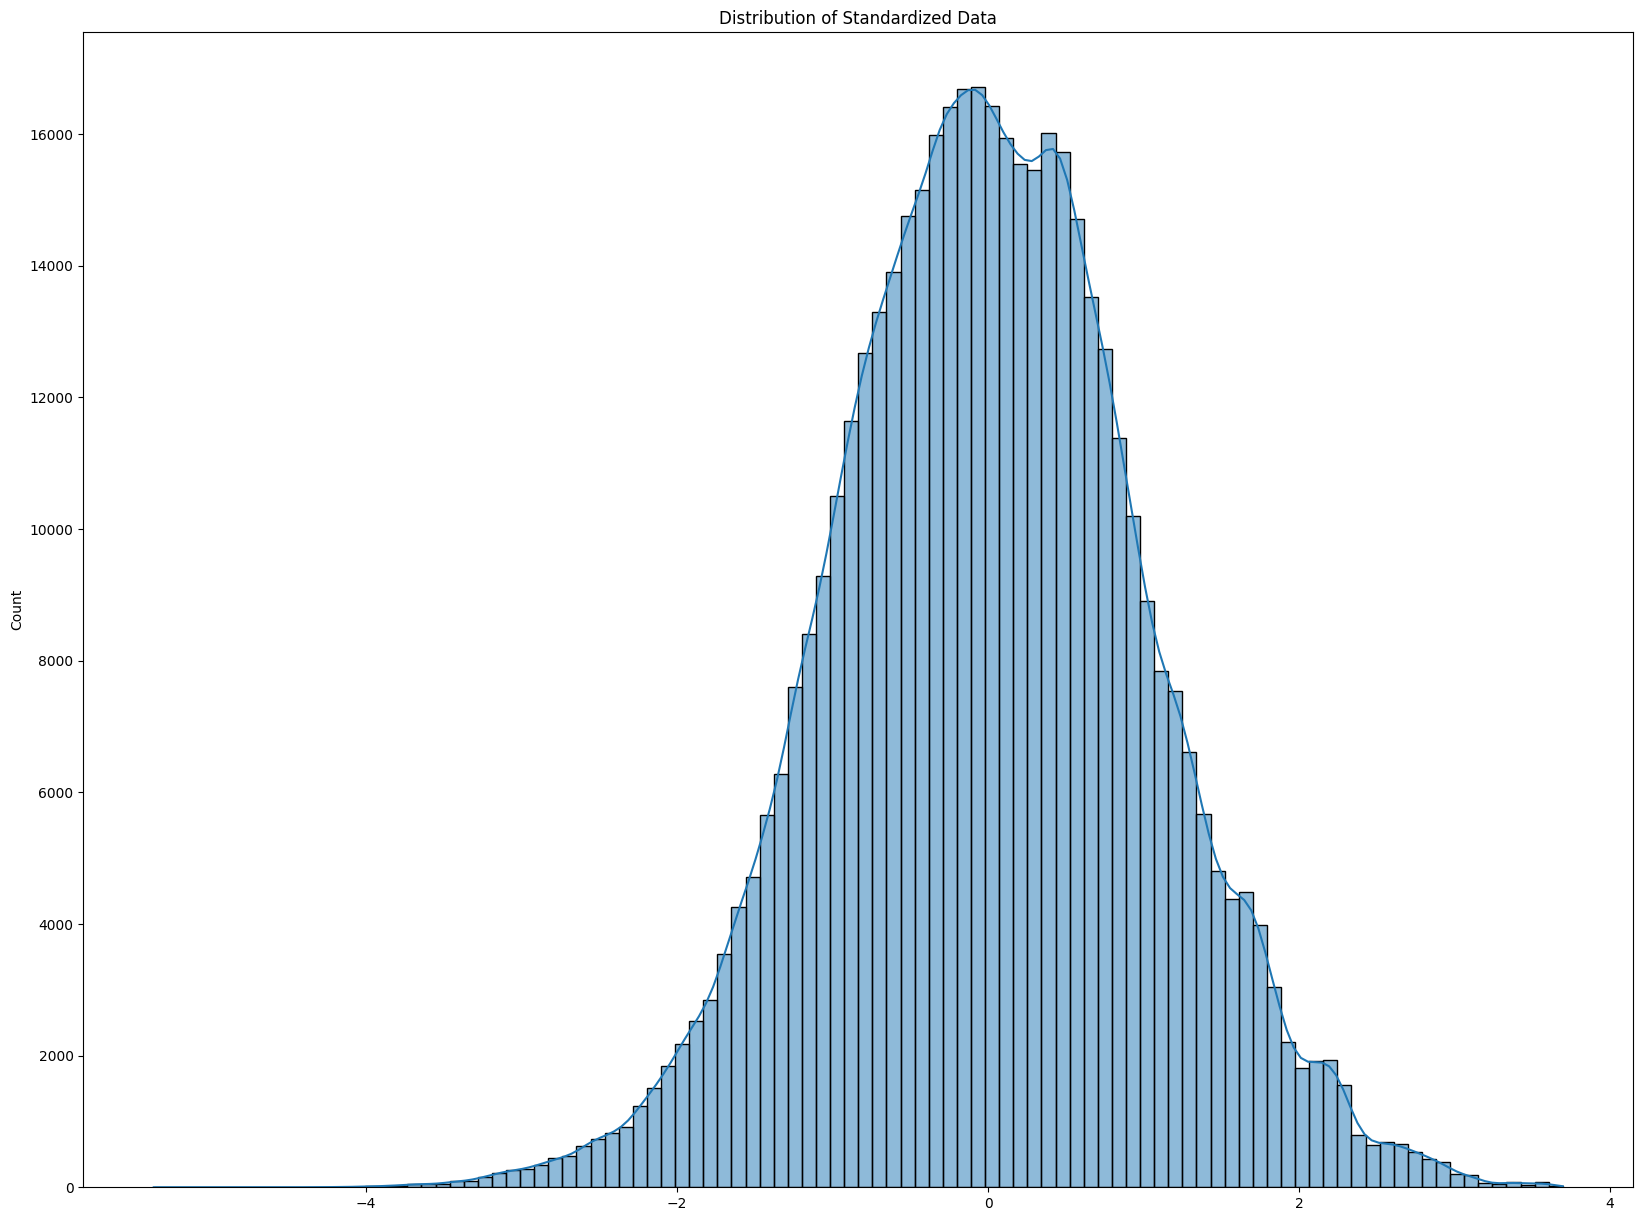

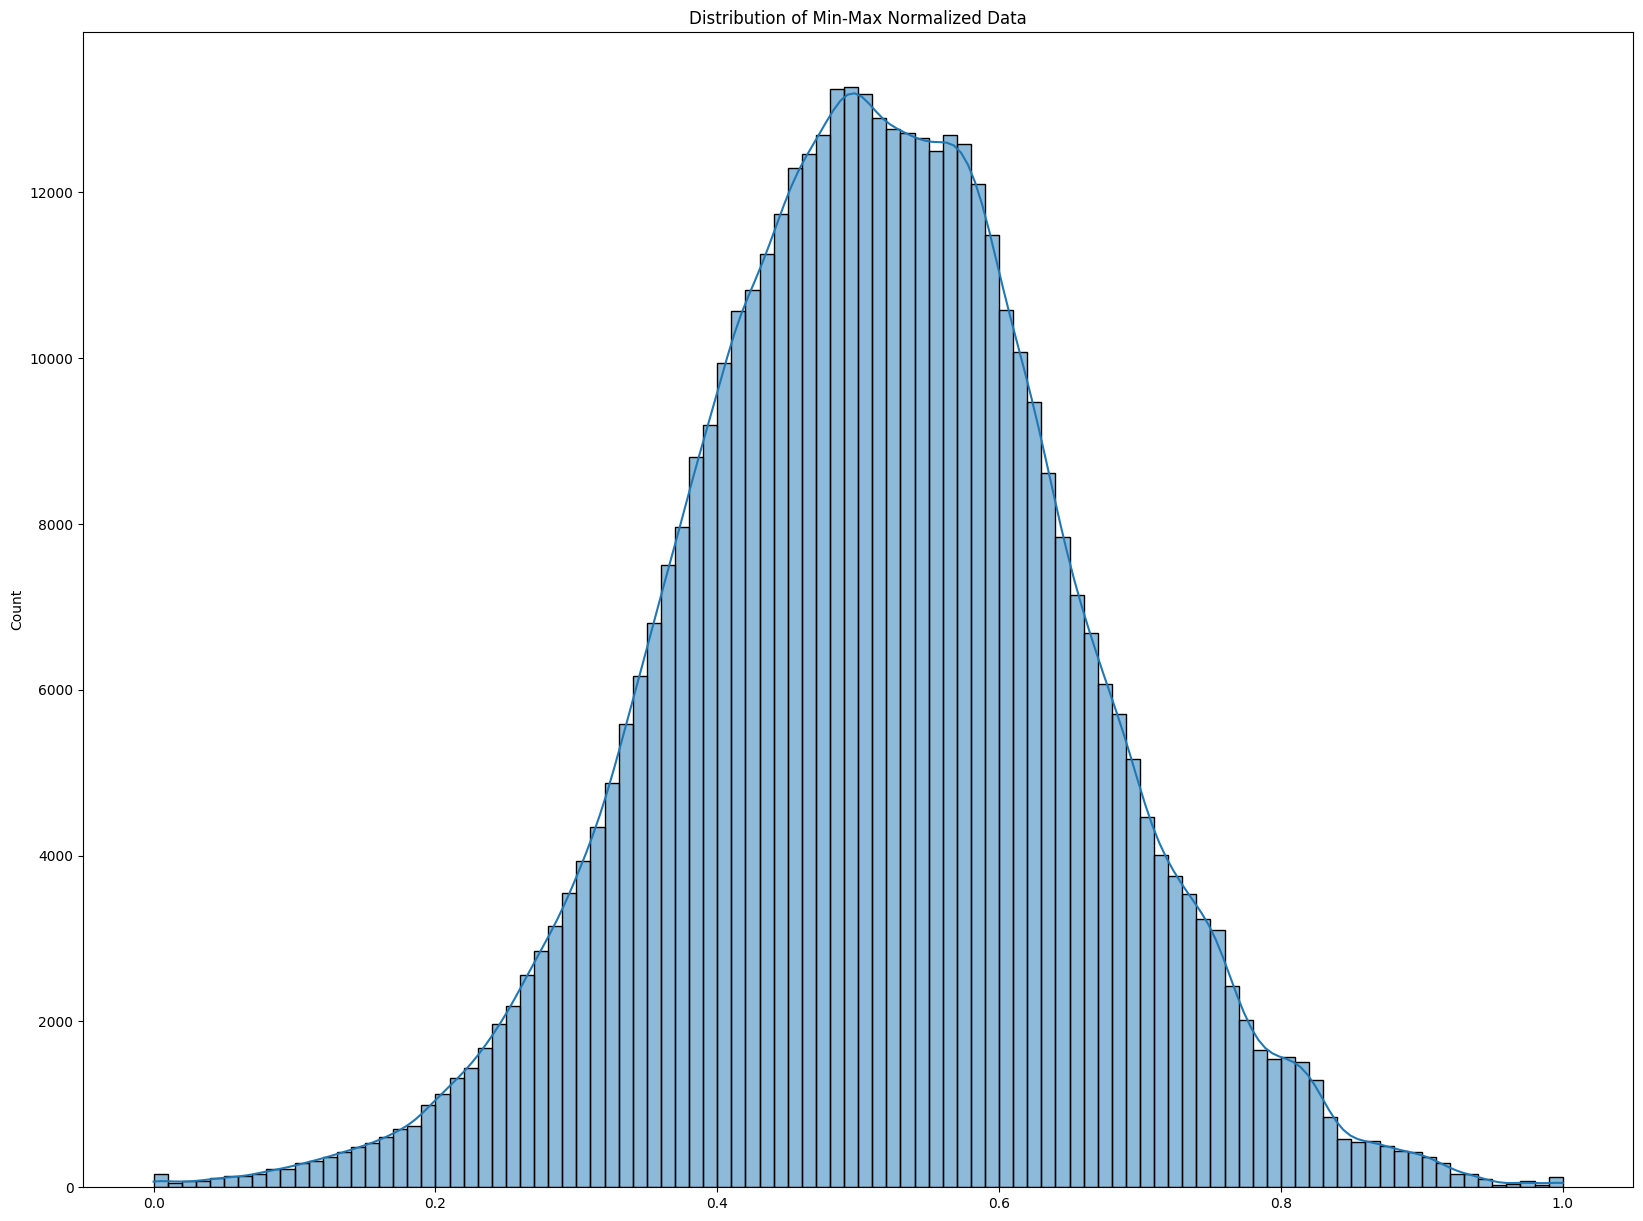

In [7]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler
# Normalization of data
# Standardization (Z-score normalization)
scaler = StandardScaler()
df_standardized = scaler.fit_transform(df_log_transformed)
print(df_standardized)
# Min-Max Normalization
min_max_scaler = MinMaxScaler()
df_min_max_scaled = min_max_scaler.fit_transform(df_log_transformed)
print(df_min_max_scaled)
#scaling
data_scaled = pd.DataFrame(data=df_min_max_scaled, columns=data_intensity.columns) 
print(data_scaled) 

# Visualizing the normalized data
plt.figure(figsize=(20, 15))
sns.histplot(df_standardized.flatten(), kde=True, bins=100,) #bins100 to make the plot more clear
plt.title("Distribution of Standardized Data")
plt.show()

plt.figure(figsize=(20, 15))
sns.histplot(df_min_max_scaled.flatten(), kde=True, bins=100) 
plt.title("Distribution of Min-Max Normalized Data")
plt.show()

7_Removal of rows containing nan values

In [8]:
#Count NaN values per row
nan_counts = data_scaled.isna().sum(axis=1).sum()   #there are totally 158 rows contating nan values in the data
print(nan_counts)

# rows with nan values are removed from a dataframe
data_filtered = data_scaled.dropna(axis=0)
print(data_filtered)

2199
      Banner.b01.127C  Banner.b01.129C  Banner.b01.129N  Banner.b01.130C  \
0            0.942877         0.939560         0.940786         0.938573   
1            0.974640         0.980065         0.979717         0.977986   
2            0.793794         0.806849         0.804411         0.797387   
3            0.797887         0.798639         0.810861         0.800212   
4            0.920762         0.926850         0.925567         0.931299   
...               ...              ...              ...              ...   
3857         0.394383         0.417473         0.394123         0.376626   
3860         0.272452         0.279223         0.309546         0.297047   
3862         0.435895         0.416044         0.395066         0.400856   
3866         0.331287         0.365588         0.336315         0.342176   
3869         0.280285         0.311146         0.308950         0.296247   

      Banner.b02.127C  Banner.b02.127N  Banner.b02.129C  Banner.b02.129N  \
0     

8_Outlier detection and removal

In [9]:
from scipy.stats import zscore

# Z-scores
z_scores = data_filtered.apply(zscore)
print(z_scores)
# threshold for identifying outliers
threshold = 3

# Rows to keep
rows_to_keep = (z_scores < threshold).all(axis=1)
# print(rows_to_keep)
# len(rows_to_keep)


data_no_outliers = data_filtered[rows_to_keep]
data_no_outliers
print(data_no_outliers)
# outliers = [(z_scores > 3).all(axis=1)]
# print(outliers)

print(f'Original data shape: {data.shape}')
print(f'Data shape after sclaing: {data_scaled.shape}')
print(f'Data shape after nan values removal: {data_filtered.shape}')
print(f'Data shape after outlier removal: {data_no_outliers.shape}')

      Banner.b01.127C  Banner.b01.129C  Banner.b01.129N  Banner.b01.130C  \
0            3.324746         3.282432         3.271530         3.285287   
1            3.555565         3.578523         3.560391         3.574566   
2            2.241391         2.312336         2.259657         2.249018   
3            2.271132         2.252322         2.307514         2.269755   
4            3.164042         3.189524         3.158608         3.231895   
...               ...              ...              ...              ...   
3857        -0.661052        -0.533954        -0.784591        -0.839242   
3860        -1.547099        -1.544545        -1.412128        -1.423326   
3862        -0.359391        -0.544401        -0.777592        -0.661395   
3866        -1.119555        -0.913228        -1.213507        -1.092094   
3869        -1.490181        -1.311191        -1.416553        -1.429200   

      Banner.b02.127C  Banner.b02.127N  Banner.b02.129C  Banner.b02.129N  \
0          

9_Prprocessed proteomic data

In [10]:
# Merging the preprocessed data with protein ID
processed_df = data_no_outliers.merge(data_protein_ID, left_index=True, right_index=True)

# Reordering the columns
cols = processed_df.columns.tolist()
new_cols = [cols[-1]] + cols[:-1]
processed_df = processed_df[new_cols]
processed_df

,Protein_ID,Banner.b01.127C,Banner.b01.129C,Banner.b01.129N,Banner.b01.130C,Banner.b02.127C,Banner.b02.127N,Banner.b02.129C,Banner.b02.129N,Banner.b02.130C,...,Banner.b21.129C,Banner.b21.130C,Banner.b21.131N,Banner.b22.127C,Banner.b22.127N,Banner.b22.128N,Banner.b22.129C,Banner.b22.129N,Banner.b22.130C,Banner.b22.130N
2,Q03001,0.793794,0.806849,0.804411,0.797387,0.811064,0.797555,0.794079,0.800812,0.801597,...,0.804142,0.801558,0.791096,0.812213,0.821614,0.811690,0.813009,0.812048,0.814030,0.812826
3,Q9UPA5,0.797887,0.798639,0.810861,0.800212,0.800206,0.784652,0.802852,0.787941,0.804468,...,0.799950,0.794441,0.801366,0.805217,0.802010,0.807331,0.816509,0.820137,0.804435,0.813558
5,Q09666,0.808218,0.838980,0.825216,0.811385,0.853693,0.834367,0.827541,0.835004,0.811437,...,0.832670,0.825140,0.821861,0.859115,0.833249,0.829033,0.827484,0.857417,0.853695,0.855357
6,Q9Y4G6,0.796770,0.807406,0.812318,0.807874,0.805791,0.800789,0.804958,0.801459,0.811822,...,0.808943,0.802452,0.801889,0.820343,0.822688,0.817395,0.817941,0.828767,0.820031,0.823254
7,O15020,0.791914,0.800303,0.800979,0.798513,0.799589,0.794195,0.792411,0.790792,0.801029,...,0.802888,0.800739,0.792251,0.803259,0.806628,0.798358,0.808641,0.806562,0.801218,0.805413
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3857,P60903,0.394383,0.417473,0.394123,0.376626,0.437584,0.468112,0.451651,0.427333,0.427344,...,0.430601,0.406089,0.427018,0.520917,0.485515,0.468673,0.472823,0.507283,0.473131,0.479685
3860,Q9BQC6,0.272452,0.279223,0.309546,0.297047,0.379732,0.371921,0.371960,0.367206,0.376301,...,0.418345,0.411141,0.407185,0.416822,0.447069,0.409027,0.438812,0.432997,0.415753,0.417396
3862,P06703,0.435895,0.416044,0.395066,0.400856,0.487932,0.497047,0.456993,0.504519,0.468704,...,0.526839,0.526270,0.514287,0.561262,0.555102,0.525273,0.550487,0.557387,0.532493,0.536646
3866,P30536,0.331287,0.365588,0.336315,0.342176,0.400886,0.388825,0.361425,0.373328,0.365640,...,0.425838,0.417118,0.414684,0.440121,0.444106,0.419355,0.444905,0.440162,0.426614,0.421193


10_Data Integration (proteomic and clinic data)

In [11]:
processed_df
# Transpose the processed dataframe and set the index to the first column (Sample)
df1_transposed = processed_df.set_index(processed_df.columns[0]).T
df1_transposed

# Merge the transposed dataframe with the metadata
merged_df = pd.merge(df1_transposed, metadata.set_index(metadata.columns[0]), left_index=True, right_index=True)
merged_df


,Q03001,Q9UPA5,Q09666,Q9Y4G6,O15020,Q02952,Q9Y490,Q12955,P35579,P49327,...,P06703,P30536,P56277,age,sex,pmi,disease_group,batch,study,batch_org
Banner.b01.127C,0.793794,0.797887,0.808218,0.796770,0.791914,0.816653,0.724105,0.758086,0.798568,0.794899,...,0.435895,0.331287,0.280285,86,0,2.50,AD,1,Banner,1
Banner.b01.129C,0.806849,0.798639,0.838980,0.807406,0.800303,0.834854,0.733493,0.755572,0.802688,0.800866,...,0.416044,0.365588,0.311146,81,1,2.83,AD,1,Banner,1
Banner.b01.129N,0.804411,0.810861,0.825216,0.812318,0.800979,0.824337,0.727744,0.763743,0.800215,0.797049,...,0.395066,0.336315,0.308950,75,0,2.75,Control,1,Banner,1
Banner.b01.130C,0.797387,0.800212,0.811385,0.807874,0.798513,0.821305,0.725272,0.763010,0.799233,0.796734,...,0.400856,0.342176,0.296247,81,0,4.00,AD,1,Banner,1
Banner.b02.127C,0.811064,0.800206,0.853693,0.805791,0.799589,0.829412,0.746777,0.761575,0.803144,0.799960,...,0.487932,0.400886,0.241778,74,0,3.00,AD,1,Banner,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Banner.b22.128N,0.811690,0.807331,0.829033,0.817395,0.798358,0.805540,0.749172,0.767103,0.805712,0.800095,...,0.525273,0.419355,0.327150,68,0,4.16,AD,1,Banner,22
Banner.b22.129C,0.813009,0.816509,0.827484,0.817941,0.808641,0.815979,0.750389,0.766205,0.811582,0.813330,...,0.550487,0.444905,0.368353,87,1,2.45,AD,1,Banner,22
Banner.b22.129N,0.812048,0.820137,0.857417,0.828767,0.806562,0.807490,0.775248,0.767442,0.821315,0.807129,...,0.557387,0.440162,0.341638,87,1,3.13,AD,1,Banner,22
Banner.b22.130C,0.814030,0.804435,0.853695,0.820031,0.801218,0.812616,0.761693,0.769010,0.800570,0.807426,...,0.532493,0.426614,0.321839,75,1,3.00,AD,1,Banner,22


11_Prepared the data to features and target

disease_group
AD         92
Control    26
Name: count, dtype: int64


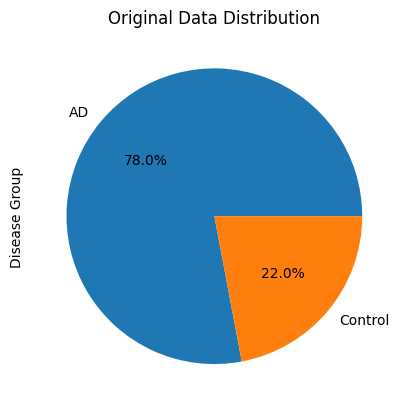

In [12]:
data = merged_df.copy()

#features of the data
x = data.iloc[:, 1:-7]       #all the intensity values of sample with respect to the proteins

#target of the data
y = data['disease_group']   #binary data (AD/control)

print(y.value_counts())

ax = y.value_counts().plot.pie(autopct='%1.1f%%')
title = ax.set_title("Original Data Distribution")
ylabel = ax.set_ylabel("Disease Group")


12_Balancing the dataset

12.1 Oversampling the minority data using SMOTE

c:\Users\Sundar Kannan\miniconda3\envs\alzheimers\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "c:\Users\Sundar Kannan\miniconda3\envs\alzheimers\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "c:\Users\Sundar Kannan\miniconda3\envs\alzheimers\Lib\subprocess.py", line 548, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\Sundar Kannan\miniconda3\envs\alzheimers\Lib\subprocess.py", line 1026, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "c:\Users\Sunda

disease_group
AD         92
Control    92
Name: count, dtype: int64


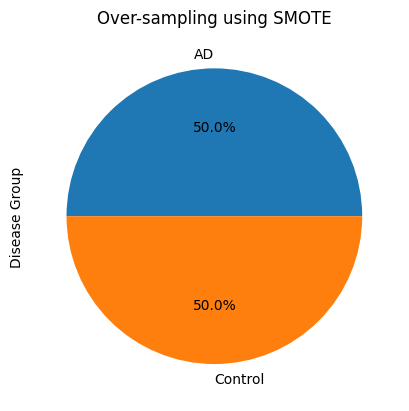

In [13]:
smote = SMOTE(random_state=42)
x_res, y_res = smote.fit_resample(x,y)

ax = y_res.value_counts().plot.pie(autopct='%1.1f%%')
title = ax.set_title("Over-sampling using SMOTE")
ylabel = ax.set_ylabel("Disease Group")
print(y_res.value_counts())

12.2 Undersampling the majority data

disease_group
AD         26
Control    26
Name: count, dtype: int64


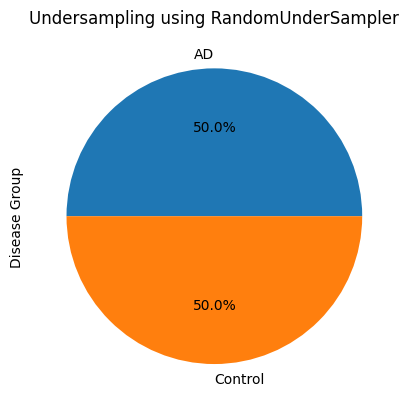

In [14]:
rus = RandomUnderSampler(random_state=42)
x_rus, y_rus = rus.fit_resample(x,y)

ax = y_rus.value_counts().plot.pie(autopct='%1.1f%%')
title = ax.set_title("Undersampling using RandomUnderSampler")
ylabel = ax.set_ylabel("Disease Group")
print(y_rus.value_counts())

13 Model performance

13.1 Model performance after data balancing using oversampling (SMOTE)

In [15]:
#Logistic regression model
x_train, x_test, y_train, y_test = train_test_split(x_res, y_res, test_size=0.2, random_state=42) #splitting the data into training and testing data
model = LogisticRegression()
model.fit(x_train, y_train) #fitting the model
y_pred = model.predict(x_test)
accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)
class_report = classification_report(y_test, y_pred)
print("LogisticRegression Model")
print(f"Accuracy: {accuracy}")
print("Confusion Matrix:")
print(conf_matrix)
print("Classification Report:")
print(class_report)
print(y_pred)

#Decision Tree model
x_train, x_test, y_train, y_test = train_test_split(x_res, y_res, test_size=0.2, random_state=42)
model = DecisionTreeClassifier()
model.fit(x_train, y_train)
y_pred = model.predict(x_test)
accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)
class_report = classification_report(y_test, y_pred)
print("Decisiontree Model")
print(f"Accuracy: {accuracy}")
print("Confusion Matrix:")
print(conf_matrix)
print("Classification Report:")
print(class_report)
print(y_pred)

#Random Forest model
x_train, x_test, y_train, y_test = train_test_split(x_res, y_res, test_size=0.2, random_state=42)
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(x_train, y_train)
y_pred = model.predict(x_test)
accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)
class_report = classification_report(y_test, y_pred)
print("Random forest Model")
print(f"Accuracy: {accuracy}")
print("Confusion Matrix:")
print(conf_matrix)
print("Classification Report:")
print(class_report)
print(y_pred)

c:\Users\Sundar Kannan\miniconda3\envs\alzheimers\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression Model
Accuracy: 0.7837837837837838
Confusion Matrix:
[[16  3]
 [ 5 13]]
Classification Report:
              precision    recall  f1-score   support

          AD       0.76      0.84      0.80        19
     Control       0.81      0.72      0.76        18

    accuracy                           0.78        37
   macro avg       0.79      0.78      0.78        37
weighted avg       0.79      0.78      0.78        37

['AD' 'AD' 'Control' 'AD' 'Control' 'Control' 'AD' 'AD' 'AD' 'AD' 'AD'
 'AD' 'AD' 'Control' 'AD' 'Control' 'Control' 'AD' 'AD' 'AD' 'Control'
 'Control' 'Control' 'AD' 'AD' 'Control' 'AD' 'AD' 'Control' 'AD' 'AD'
 'Control' 'Control' 'Control' 'AD' 'Control' 'Control']
Decisiontree Model
Accuracy: 0.9459459459459459
Confusion Matrix:
[[18  1]
 [ 1 17]]
Classification Report:
              precision    recall  f1-score   support

          AD       0.95      0.95      0.95        19
     Control       0.94      0.94      0.94        18

    accuracy     

13.2 Model performance after data balancing using undersampling

In [16]:
#Logistic regression model
x_train, x_test, y_train, y_test = train_test_split(x_rus, y_rus, test_size=0.2, random_state=42) #splitting the data into training and testing data
model = LogisticRegression()
model.fit(x_train, y_train) #fitting the model
y_pred = model.predict(x_test)
accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)
class_report = classification_report(y_test, y_pred)
print("LogisticRegression Model")
print(f"Accuracy: {accuracy}")
print("Confusion Matrix:")
print(conf_matrix)
print("Classification Report:")
print(class_report)
print(y_pred)

#Decision Tree model
x_train, x_test, y_train, y_test = train_test_split(x_rus, y_rus, test_size=0.2, random_state=42)
model = DecisionTreeClassifier()
model.fit(x_train, y_train)
y_pred = model.predict(x_test)
accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)
class_report = classification_report(y_test, y_pred)
print("Decisiontree Model")
print(f"Accuracy: {accuracy}")
print("Confusion Matrix:")
print(conf_matrix)
print("Classification Report:")
print(class_report)
print(y_pred)

#Random Forest model
x_train, x_test, y_train, y_test = train_test_split(x_rus, y_rus, test_size=0.2, random_state=42)
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(x_train, y_train)
y_pred = model.predict(x_test)
accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)
class_report = classification_report(y_test, y_pred)
print("Random forest Model")
print(f"Accuracy: {accuracy}")
print("Confusion Matrix:")
print(conf_matrix)
print("Classification Report:")
print(class_report)
print(y_pred)

c:\Users\Sundar Kannan\miniconda3\envs\alzheimers\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression Model
Accuracy: 0.7272727272727273
Confusion Matrix:
[[4 2]
 [1 4]]
Classification Report:
              precision    recall  f1-score   support

          AD       0.80      0.67      0.73         6
     Control       0.67      0.80      0.73         5

    accuracy                           0.73        11
   macro avg       0.73      0.73      0.73        11
weighted avg       0.74      0.73      0.73        11

['AD' 'Control' 'Control' 'Control' 'Control' 'AD' 'AD' 'Control' 'AD'
 'AD' 'Control']
Decisiontree Model
Accuracy: 0.9090909090909091
Confusion Matrix:
[[5 1]
 [0 5]]
Classification Report:
              precision    recall  f1-score   support

          AD       1.00      0.83      0.91         6
     Control       0.83      1.00      0.91         5

    accuracy                           0.91        11
   macro avg       0.92      0.92      0.91        11
weighted avg       0.92      0.91      0.91        11

['AD' 'Control' 'Control' 'Control' 'Control